In [1]:
import sys
sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('text', usetex=True)
matplotlib.rcParams['text.latex.preamble'] = r"\usepackage{amsmath,amssymb}"
plt.style.use('plots.mplstyle')
import warnings
from py_code import XGB_test_model
warnings.filterwarnings('ignore')
from matplotlib.patches import Patch
from pathlib import Path
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D

# Evaluate Gamma - Hadron Discrimination Performance

This code finds the best threshold probability and evaluates proton-residual-fraction (or proton efficiency) at 80% gamma efficiency. It plots probability distirbutions at event level for gammas and protons and makes muon-counting plots.

- **WARNING** : Threshold is found on "test" events, in theory it should be tuned on validation events and then deployed on test
- Please label savefiles descriptively and uniquely in the pictures/

In [ ]:
# Specify txt files with probabilities
PROTONS_txt_dir = Path("../output_files_ML/HAWCSim_array/test_protons/100160TeV_025deg_4FF_180R175h_Black/13petrain_13petest_500ns/")
GAMMAS_txt_dir = Path("../output_files_ML/HAWCSim_array/test_gammas/100160TeV_025deg_4FF_180R175h_Black/13petrain_13petest_500ns/")

In [2]:
protons_info = []
gammas_info = []

for txt_file in PROTONS_txt_dir.glob("*.txt"):
    name = txt_file.stem   
    txt_file_name = str(txt_file)
    rc, pr, y_te, p_te  = np.loadtxt(txt_file_name).T    
    protons_info.append((p_te.tolist(),y_te.tolist()))

for txt_file in GAMMAS_txt_dir.glob("*.txt"):
    name = txt_file.stem   
    txt_file_name = str(txt_file)
    rc, pr, y_te, p_te  = np.loadtxt(txt_file_name).T    
    gammas_info.append((p_te.tolist(),y_te.tolist()))

In [3]:
def find_best_threshold(protons_info, gammas_info, target_eff = 0.8):

    fprs = []
    thresholds = np.linspace(0, 1, 100)
    
    for t in thresholds:

        hist_protons = []
        hist_gammas = []
        
        for i in range(len(protons_info)):
            
            info_single_proton = protons_info[i]

            p_proton = np.asarray(info_single_proton[0])
            y_proton = np.asarray(info_single_proton[1])
    
            p_proton_above_cut = np.sum(p_proton[p_proton >= t])
        
            hist_protons.append(p_proton_above_cut)
            

        for i in range(len(gammas_info)):
            
            info_single_gamma = gammas_info[i]

            p_gamma = np.asarray(info_single_gamma[0])
            y_gamma = np.asarray(info_single_gamma[1])
    
            p_gamma_above_cut = np.sum(p_gamma[p_gamma >= t])
        
            hist_gammas.append(p_gamma_above_cut)

    
        thresh = np.percentile(hist_gammas, target_eff * 100)
    
        proton_fpr = np.sum(hist_protons <= thresh) / len(hist_protons)
    
        fprs.append(proton_fpr)

    best_index = np.nanargmin(fprs)
    best_threshold = thresholds[best_index]
    min_fpr = fprs[best_index]

    print(f"Gamma efficiency target = {target_eff}")
    print(f"Min FPR = {min_fpr}")
    print(f"Best_threshold FPR = {best_threshold}")

    return best_threshold, min_fpr

In [4]:
best_threshold, min_fpr = find_best_threshold(protons_info, gammas_info)

Gamma efficiency target = 0.8
Min FPR = 0.004885993485342019
Best_threshold FPR = 0.7474747474747475


In [5]:
hist_protons = []
hist_gammas = []

for i in range(len(protons_info)):
    info_single_proton = protons_info[i]
    p_proton = np.asarray(info_single_proton[0])
    p_proton_above_cut = np.sum(p_proton[p_proton >= best_threshold])   
    hist_protons.append(p_proton_above_cut)

for i in range(len(gammas_info)):
    info_single_gamma = gammas_info[i]
    p_gamma = np.asarray(info_single_gamma[0])
    p_gamma_above_cut = np.sum(p_gamma[p_gamma >= best_threshold])   
    hist_gammas.append(p_gamma_above_cut)

In [6]:
from matplotlib.legend_handler import HandlerBase
import matplotlib.transforms as mtransforms 

class OffsetHandler(HandlerBase):
    def __init__(self, x_offset=0, y_offset=0, **kwargs):
        self.x_offset = x_offset
        self.y_offset = y_offset
        super().__init__(**kwargs)

    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):
        # Use the same type as the original handle
        patch = Rectangle(
            (0, 0), width, height,
            facecolor=orig_handle.get_facecolor(),
            edgecolor=orig_handle.get_edgecolor(),
            linewidth=orig_handle.get_linewidth()
        )
        # Apply offset
        offset_transform = trans + mtransforms.Affine2D().translate(self.x_offset, self.y_offset)
        patch.set_transform(offset_transform)
        return [patch]

In [7]:
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerLine2D
class OffsetLineHandler(HandlerLine2D):
    def __init__(self, x_offset=0, y_offset=0, **kwargs):
        super().__init__(**kwargs)
        self.x_offset = x_offset
        self.y_offset = y_offset

    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):

        line = super().create_artists(
            legend, orig_handle, xdescent, ydescent,
            width, height, fontsize, trans
        )[0]

        line.set_transform(
            line.get_transform() +
            plt.matplotlib.transforms.Affine2D().translate(self.x_offset, self.y_offset)
        )

        return [line]

Mean Protons =  15.755280130293164
Mean Gammas =  3.037883227176221
Gamma 80% threshold =  4.385
Number of protons in 80% gamma region =  3
Fraction of protons kept =  0.004885993485342019


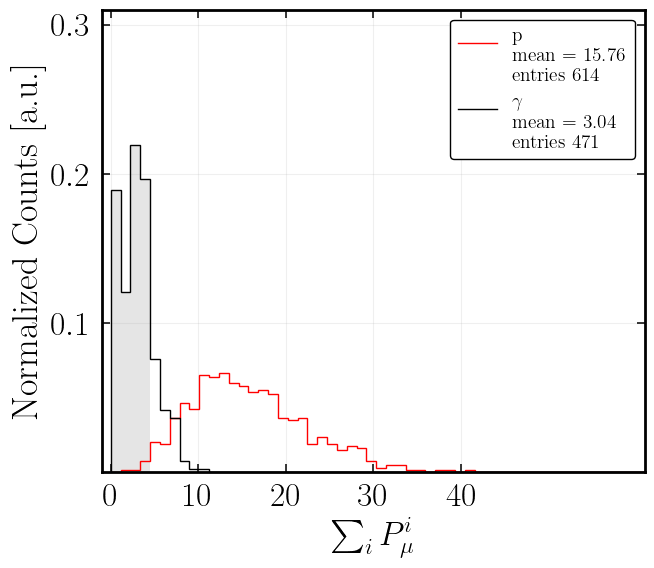

In [8]:
gammas = np.array(hist_gammas)
protons = np.array(hist_protons)

threshold = np.percentile(gammas, 80)
protons_in_region = protons[(protons >= 0) & (protons <= threshold)]

print("Mean Protons = ", np.mean(hist_protons))
print("Mean Gammas = ", np.mean(hist_gammas))
print("Gamma 80% threshold = ", threshold)
print("Number of protons in 80% gamma region = ", len(protons_in_region))
print("Fraction of protons kept = ", len(protons_in_region)/len(protons))

bins = np.linspace(0, 100, 90)
gamma_hist, edges = np.histogram(gammas, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])
mask = edges[:-1] < threshold

plt.figure(figsize=(7,6))

plt.hist(protons, color="red", histtype="step", label="p",
         density=True, bins=bins)

plt.hist(gammas, color="black", histtype="step",
         label=r"$\gamma$", density=True, bins=bins, linewidth = 1)

plt.bar(centers[mask], gamma_hist[mask], width=np.diff(edges)[mask],
        align="center", alpha = 0.1, color="black", edgecolor="none")

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

handles = [
    Line2D([0], [0], color="red", linewidth=1),
    Line2D([0], [0], color="black", linewidth=1)
]

labels = [
    r"p" + "\n" f"mean = {np.mean(protons):.2f}" + "\n" f"entries {len(protons)}",
    r" $\gamma$" + "\n" f"mean = {np.mean(gammas):.2f}" + "\n" f"entries {len(gammas)}"
]

plt.xticks([0, 10, 20, 30, 40])
plt.yticks([0, 0.1, 0.2, 0.3])

plt.tick_params(axis="both", which="major", labelsize=24, length=6)
plt.minorticks_off()
plt.xlabel(r"$\sum_{i} P_{\mu}^{i}$", fontsize=24)
plt.ylabel(r"Normalized Counts [a.u.]", fontsize=26)
plt.grid(True, alpha=0.2)

plt.xlim(-1,61)
plt.ylim(1e-4, 3.1e-1)

plt.legend(handles=handles,labels=labels,handler_map={Line2D: OffsetLineHandler(y_offset=13)},edgecolor="black",facecolor="white",framealpha=1.0,fontsize=14)

plt.savefig("../pictures/100160TeV_025deg_4FF_180R175h_Black/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/cumprobdist_pgamma_100160TeV_25z_13pe_500ns_0600d.pdf", dpi=300, bbox_inches="tight")
plt.show()

Mean Protons =  15.755280130293164
Mean Gammas =  3.037883227176221
Gamma 80% threshold =  4.385
Number of protons in 80% gamma region =  3
Fraction of protons kept =  0.004885993485342019


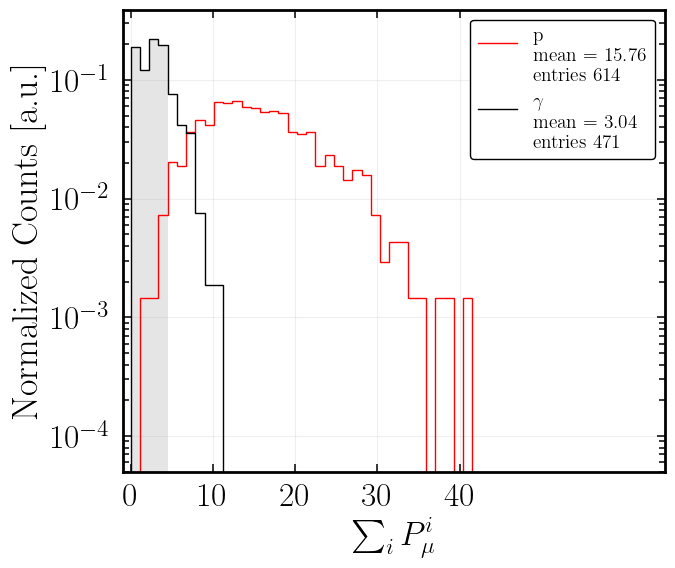

In [9]:
gammas = np.array(hist_gammas)
protons = np.array(hist_protons)

threshold = np.percentile(gammas, 80)
protons_in_region = protons[(protons >= 0) & (protons <= threshold)]

print("Mean Protons = ", np.mean(hist_protons))
print("Mean Gammas = ", np.mean(hist_gammas))
print("Gamma 80% threshold = ", threshold)
print("Number of protons in 80% gamma region = ", len(protons_in_region))
print("Fraction of protons kept = ", len(protons_in_region)/len(protons))

bins = np.linspace(0, 100, 90)
gamma_hist, edges = np.histogram(gammas, bins=bins, density=True)
centers = 0.5 * (edges[:-1] + edges[1:])
mask = edges[:-1] < threshold

plt.figure(figsize=(7,6))

plt.hist(protons, color="red", histtype="step", label="p",
         density=True, bins=bins)

plt.hist(gammas, color="black", histtype="step",
         label=r"$\gamma$", density=True, bins=bins, linewidth = 1)

plt.bar(centers[mask], gamma_hist[mask], width=np.diff(edges)[mask],
        align="center", alpha = 0.1, color="black", edgecolor="none")

for spine in plt.gca().spines.values():
    spine.set_linewidth(2)

labels = [
    r"p" + "\n" f"mean = {np.mean(protons):.2f}" + "\n" f"entries {len(protons)}",
    r" $\gamma$" + "\n" f"mean = {np.mean(gammas):.2f}" + "\n" f"entries {len(gammas)}"
]

handles = [
    Line2D([0], [0], color="red", linewidth=1),
    Line2D([0], [0], color="black", linewidth=1)
]

plt.xticks([0, 10, 20, 30, 40])
plt.yticks([0, 0.1, 0.2, 0.3])

plt.tick_params(axis="both", which="major", labelsize = 24, length = 6)
plt.minorticks_off()
plt.xlabel(r"$\sum_{i} P_{\mu}^{i}$", fontsize=24)
plt.ylabel(r"Normalized Counts [a.u.]", fontsize=26)
plt.grid(True, alpha=0.2)
plt.yscale("log")

plt.xlim(-1,65)
plt.ylim(0.5e-4, 3.9e-1)


plt.legend(handles=handles,labels=labels,handler_map={Line2D: OffsetLineHandler(y_offset=13)},edgecolor="black",facecolor="white",framealpha=1.0,fontsize=14)
plt.savefig("../pictures/100160TeV_025deg_4FF_180R175h_Black/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/logcumprobdist_pgamma_100160TeV_25z_13pe_500ns_0600d.pdf", dpi=300, bbox_inches="tight")
plt.show()

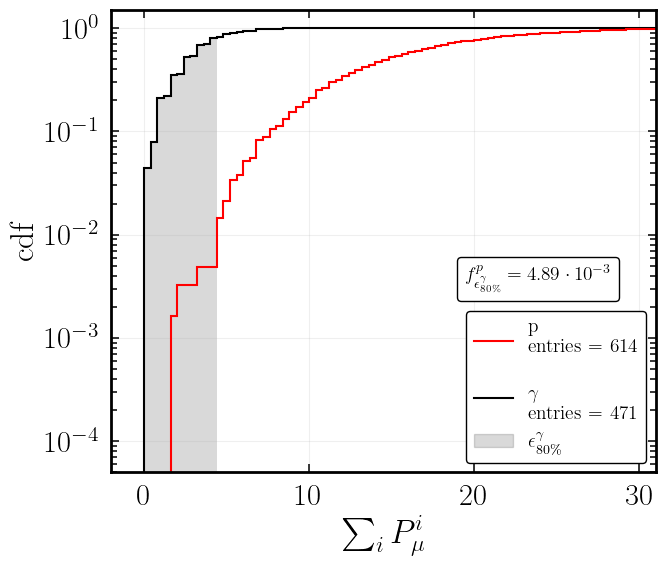

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

counts_g, bins_g, _ = ax.hist(gammas, bins=150, histtype="step", color="black", linewidth=1.5, cumulative=1, density=True, range=(0,60))
ax.hist(protons, bins=150, histtype="step", color="red", linewidth=1.5, cumulative=1, density=True, range=(0,60))

threshold = np.percentile(gammas, 80)

centers = 0.5 * (bins_g[:-1] + bins_g[1:])
mask = centers <= threshold

ax.bar(centers[mask], counts_g[mask], width=np.diff(bins_g)[mask], align="center", color="black", alpha=0.15, edgecolor="none")

for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.tick_params(axis="both", which="major", labelsize=22, length=6)
ax.minorticks_off()

ax.set_xlabel(r"$\sum_{i} P_{\mu}^{i}$", fontsize=24)
ax.set_ylabel("cdf", fontsize=24)

ax.set_yscale("log")
ax.set_ylim(0.5e-4, 1.5)
ax.set_xlim(-2,31)

ax.grid(True, alpha=0.2)

handles = [
    plt.Line2D([0], [0], color="red", linewidth=1.5),
    plt.Line2D([0], [0], color="black", linewidth=1.5),
    plt.Rectangle((0, 0), 1, 1, color="black", alpha=0.15)
]

labels = [
    f"p\nentries = {len(protons)} \n",
    f"$\\gamma$\nentries = {len(gammas)}",
    "$\epsilon^{\gamma}_{80 \%}$"
]

f_p = np.sum(protons <= threshold) / len(protons)
mantissa, exponent = f"{f_p:.2e}".split("e")

legend_text = ax.legend([plt.Line2D([], [], linestyle="none")],
                        [rf"$f^p_{{\epsilon^{{\gamma}}_{{80\%}}}} = {float(mantissa):.2f}\cdot10^{{{int(exponent)}}}$"],
                        fontsize=14,
                        edgecolor="black",
                        facecolor="white",
                        framealpha=1.0,
                        loc="lower right",
                        bbox_to_anchor=(0.95, 0.35),
                        handlelength=0,
                        handletextpad=0)
ax.legend(handles, labels, fontsize=14, edgecolor="black", facecolor="white", framealpha=1.0, loc="lower right", handler_map={Line2D: OffsetLineHandler(y_offset=6)})


ax.add_artist(legend_text)

plt.tight_layout()
plt.savefig("../pictures/100160TeV_025deg_4FF_180R175h_Black/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/cdf_pgamma_100160TeV_25z_13pe_500ns_0600d.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
def get_S_to_B_ratio(gammas: np.ndarray, protons: np.ndarray):
    
    S_list = []
    B_list = []
    S_to_sqrtB_list = []

    for percentile in np.linspace(0, 1, 20):
        thresh = np.percentile(gammas, percentile*100)  

        S = np.sum(gammas <= thresh) / len(gammas)
        B = np.sum(protons <= thresh) / len(protons)
        
        S_list.append(S)
        B_list.append(B)

        if B > 0:
            S_to_sqrtB_list.append(S / np.sqrt(B))
        else:
            S_to_sqrtB_list.append(0)

    return S_list, S_to_sqrtB_list

In [12]:
def compute_roc(gammas: np.ndarray, protons: np.ndarray, n_points: int = 200):
    thresholds = np.linspace(
        min(gammas.min(), protons.min()),
        max(gammas.max(), protons.max()),
        n_points
    )

    tpr = []
    fpr = []

    for thresh in thresholds:
        tpr.append(np.sum(gammas <= thresh) / len(gammas))
        fpr.append(np.sum(protons <= thresh) / len(protons))

    return np.array(fpr), np.array(tpr), thresholds

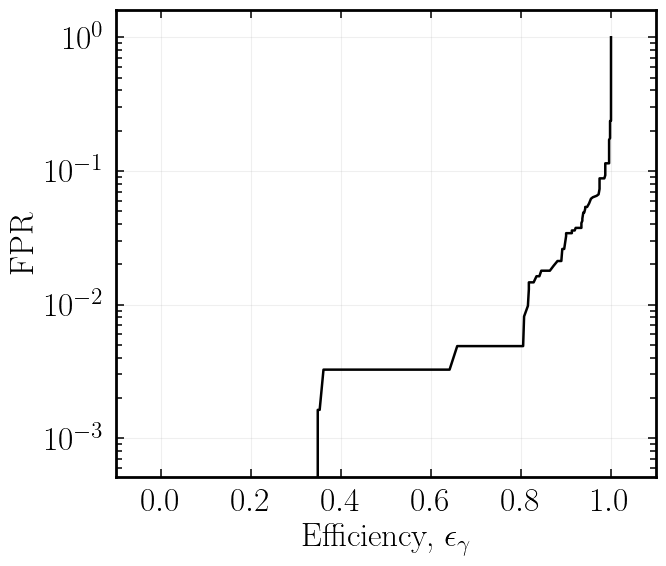

In [13]:
fpr, tpr, thr = compute_roc(gammas, protons, n_points = 1000)
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(tpr, fpr, color="black", linewidth=1.8)

for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.tick_params(axis="both", which="major", labelsize=24, length=6)
ax.minorticks_off()

ax.set_xlabel(r"Efficiency, $\epsilon_{\gamma}$", fontsize=24)
ax.set_ylabel("FPR", fontsize=24)


ax.set_yscale("log")
#ax.set_xscale("log")
ax.set_xlim(-0.1, 1.1)
ax.set_ylim(0.51e-3, 1.6)

ax.grid(True, alpha=0.2)
plt.xticks([0, 0.20, 0.40, 0.60, 0.80, 1])

handles = [
    plt.Line2D([0], [0], color="black", linewidth=1.8),
]

#ax.legend(handles, labels, fontsize=18, edgecolor="black", facecolor="white", framealpha=1.0, loc = "upper left")

plt.tight_layout()
plt.savefig("../pictures/100160TeV_025deg_4FF_180R175h_Black/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/fpr_vs_effgamma_100160TeV_25z_13pe_500ns_0600d.pdf", dpi=300, bbox_inches="tight")
data = np.column_stack([tpr, fpr])
np.savetxt(fname  = "../results_files_ML/100160TeV_025deg_4FF_180R290h_Black_13peSM_13peBKG_13peTEST_d0600_500ns", X = data, delimiter = ' ', header = "geff peff")

plt.show()

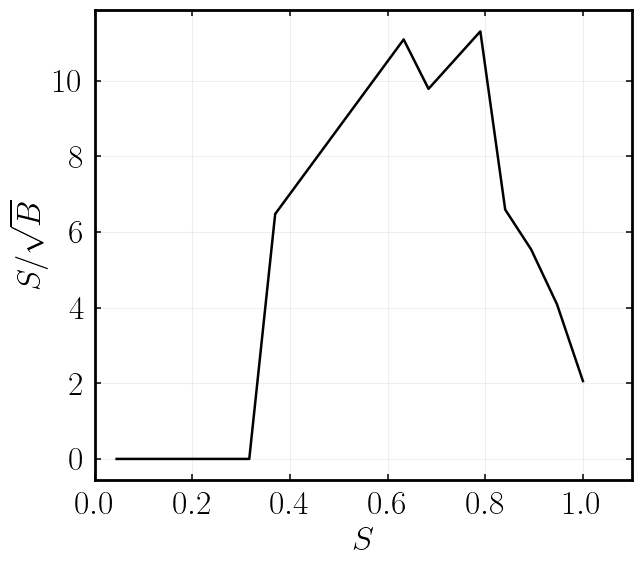

In [14]:
S, S_to_sqrtB_list = get_S_to_B_ratio(gammas, protons)

fig, ax = plt.subplots(figsize=(7, 6))

# main curve
ax.plot(S, S_to_sqrtB_list, color="black", linewidth=1.8)

# spines
for spine in ax.spines.values():
    spine.set_linewidth(2)

# ticks
ax.tick_params(axis="both", which="major", labelsize=24, length=4)
ax.minorticks_off()

# labels
ax.set_xlabel(r"$S$", fontsize=24)
ax.set_ylabel(r"$S/\sqrt{B}$", fontsize=24)

# limits
ax.set_xlim(0, 1.1)

# grid (subtle)
ax.grid(True, alpha=0.2)

# optional: clean x ticks like before
ax.set_xticks([0, 0.20, 0.40, 0.60, 0.80, 1.0])

plt.tight_layout()
plt.savefig("../pictures/100160TeV_025deg_4FF_180R175h_Black/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/SignaltoNoiseRatio_100160TeV_25z_13pe_500ns_0600d.pdf", dpi=300, bbox_inches="tight")

plt.show()

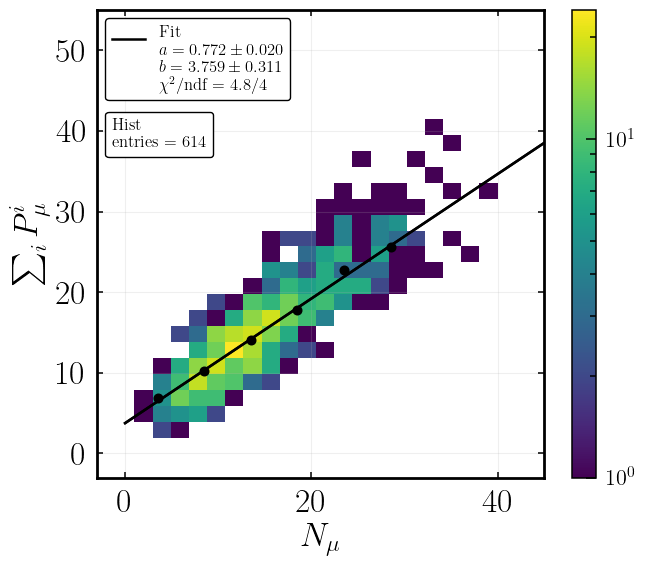

In [15]:
#################### ONLY PROBABILITIES ABOVE THRESHOLD, ALL MUONS RECORDED #######################
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from iminuit import Minuit

n_muons = []
p_cum = []

for i in range(len(protons_info)):
    info_single_proton = protons_info[i]

    p_proton = np.asarray(info_single_proton[0])
    y_proton = np.asarray(info_single_proton[1])

    mask_thr = p_proton >= best_threshold
    p_proton = p_proton[mask_thr]

    n_muons_proton = np.nansum(y_proton == 1)
    p_cum_proton = np.nansum(p_proton)

    n_muons.append(n_muons_proton)
    p_cum.append(p_cum_proton)

n_muons = np.asarray(n_muons)
p_cum = np.asarray(p_cum)

bin_width = 5
n_min = np.min(n_muons)
n_max = np.max(n_muons)

bins = np.arange(n_min, n_max + bin_width, bin_width)

bin_centers = []
mean_pr = []
err_pr = []
p_bin_centers = []

for i in range(len(bins) - 1):
    mask_bin = (n_muons >= bins[i]) & (n_muons < bins[i + 1])
    p_cum_bin = p_cum[mask_bin]  
    

    if len(p_cum_bin) > 20:
        bin_centers.append(0.5 * (bins[i] + bins[i + 1]))
        mean_pr.append(np.mean(p_cum_bin))
        err_pr.append(np.std(p_cum_bin) / np.sqrt(len(p_cum_bin)))
        p_bin_centers.append(p_cum_bin)

bin_centers = np.asarray(bin_centers)
mean_pr = np.asarray(mean_pr)
err_pr = np.asarray(err_pr)

def linear_regr(x, a, b):
    return a * x + b

def chi2(a, b):
    return np.sum(((mean_pr - linear_regr(bin_centers, a, b)) / err_pr) ** 2)

m = Minuit(chi2, a = 1.0, b = 0.0)
m.errordef = Minuit.LEAST_SQUARES
m.migrad()
m.hesse()

chi2_val = m.fval
ndf = len(mean_pr) - len(m.parameters)

n_fit = np.linspace(0, 100, 300)
p_fit = linear_regr(n_fit, *m.values)

fig, ax = plt.subplots(figsize=(7, 6))

h = ax.hist2d(n_muons, p_cum, bins = 20, cmap="viridis", norm=colors.LogNorm(vmin=1))

ax.errorbar(bin_centers, mean_pr, yerr=err_pr, fmt="o", color="black", markersize=6, elinewidth=1.4, ecolor="black", markeredgecolor="black", markeredgewidth=1.2)
ax.plot(n_fit, p_fit, color="black", linewidth=1.8, label=(f"$a = {m.values['a']:.3f} \\pm {m.errors['a']:.3f}$\n" f"$b = {m.values['b']:.3f} \\pm {m.errors['b']:.3f}$\n" f"$\\chi^2$/ndf = {chi2_val:.1f}/{ndf}\nentries = {len(n_muons)}"))
for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.tick_params(axis="both", which="major", labelsize=24, length=4)
ax.minorticks_off()

ax.set_xlabel("$N_{\mu}$", fontsize=24)
ax.set_ylabel(r"$\sum_i P_{\mu}^{i}$", fontsize=24)

ax.set_xlim(-3, n_max + 5)
#ax.set_ylim(-3, np.max(p_cum) + 5)
ax.set_ylim(-3, 55)

ax.grid(True, alpha=0.2)

cbar = plt.colorbar(h[3], ax=ax)
cbar.ax.tick_params(labelsize=16)

fit_line, = ax.plot(n_fit, p_fit, color="black", linewidth=1.8)

legend_fit = ax.legend([fit_line], [f"Fit\n$a = {m.values['a']:.3f} \\pm {m.errors['a']:.3f}$\n$b = {m.values['b']:.3f} \\pm {m.errors['b']:.3f}$\n$\\chi^2$/ndf = {chi2_val:.1f}/{ndf}"], fontsize=12, edgecolor="black", facecolor="white", framealpha=1.0, loc="upper left",handler_map={Line2D: OffsetLineHandler(y_offset=20)})
legend_data = ax.legend([plt.Line2D([], [], linestyle="none")], [f"Hist\nentries = {len(n_muons)}"], fontsize=12, edgecolor="black", facecolor="white", framealpha=1.0, loc="upper left", bbox_to_anchor=(0.0, 0.80), handlelength=0, handletextpad=0)
ax.add_artist(legend_fit)

plt.tight_layout()
plt.savefig("../pictures/100160TeV_025deg_4FF_180R175h_Black/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/pmuOTvsnmuNOT_bin5lenbin20_100160TeV_25z_13pe_500ns_0600d.pdf", dpi=300, bbox_inches="tight")

plt.show()

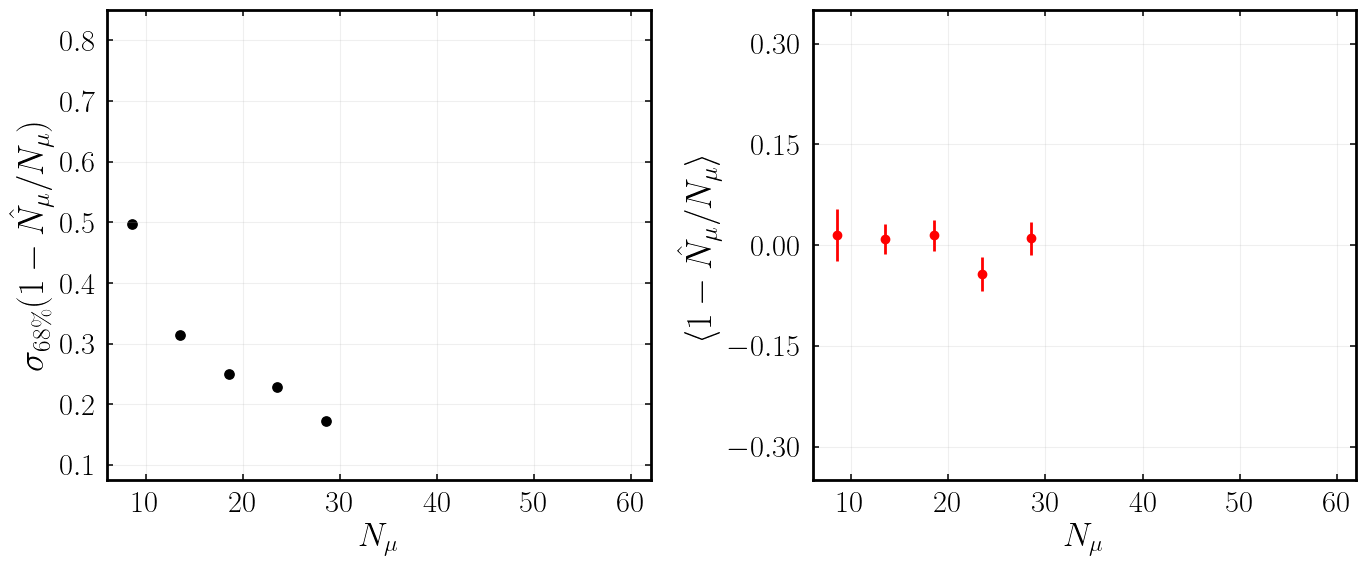

In [16]:
def n_estimated(m, q, p):
    a = 1 / m
    b = -q / m
    return a * p + b

m_ = m.values[0]
q_ = m.values[1]

def estimator(n_reco_, n_muons_):
    return 1 - n_reco_ / n_muons_

est_list = []
for i in range(len(bin_centers)):
    est = [1 - (n_estimated(m_, q_, p_bin_centers[i][j]) / bin_centers[i]) for j in range(len(p_bin_centers[i]))]
    est_list.append(est)

resolution = np.asarray([(np.percentile(k, 84) - np.percentile(k, 16)) / 2 for k in est_list])
bias = np.asarray([np.mean(k) for k in est_list])

bias_err = np.asarray([np.std(k, ddof=1) / np.sqrt(len(k)) if len(k) > 1 else np.nan for k in est_list])

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].scatter(bin_centers, resolution, color="black", s=45, edgecolors="black", linewidths=1.0)
ax[1].errorbar(bin_centers, bias, yerr = bias_err, fmt="o", color="red", markersize=6, ecolor="red", markeredgecolor="red", markeredgewidth=1.0)

for i in range(2):
    for spine in ax[i].spines.values():
        spine.set_linewidth(2)
    ax[i].tick_params(axis="both", which="major", labelsize=22, length=4)
    ax[i].minorticks_off()
    ax[i].grid(True, alpha=0.2)
    ax[i].set_xlim(np.min(bin_centers) - 5, np.max(bin_centers) + 5)
    ax[i].set_xlabel(r"$N_{\mu}$", fontsize=24)

ax[0].set_ylabel(r" $\sigma_{68 \%} (1 - \hat{N_{\mu}}/N_{\mu})$", fontsize=26)
ax[1].set_ylabel(r"$\langle 1 - \hat{N}_{\mu}/N_{\mu} \rangle$", fontsize=26)

ax[0].set_xticks([0, 10, 20, 30, 40, 50, 60, 70])
ax[1].set_xticks([0, 10, 20, 30, 40, 50, 60, 70])

ax[0].set_yticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
ax[1].set_yticks([-0.3, -0.15, 0, 0.15, 0.3])

ax[0].set_ylim(0.075, 0.85)
ax[1].set_ylim(-0.35, 0.35)
ax[0].set_xlim(6, 62)
ax[1].set_xlim(6, 62)

plt.tight_layout()
plt.savefig("../pictures/100160TeV_025deg_4FF_180R175h_Black/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/bias_variance_pmuOT_nmuNOT_bin5lenbin20_100160TeV_25z_13pe_500ns_0600d.pdf", dpi=300, bbox_inches="tight")
plt.show()

Mean number of muons =  15.017915309446254


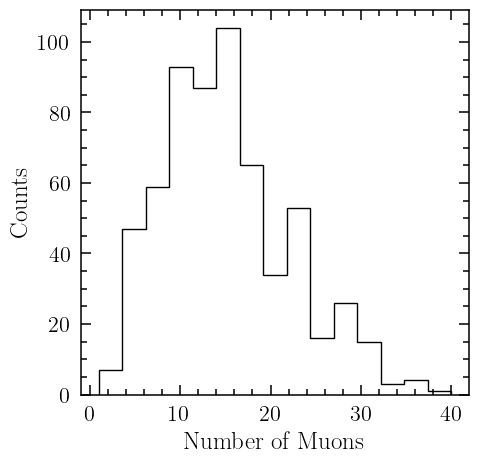

In [17]:
plt.hist(n_muons, color = "black", histtype = "step", bins = 15)
print("Mean number of muons = ", np.mean(n_muons))
plt.xlabel("Number of Muons")
plt.ylabel("Counts")
plt.show()

Delta N statistics:
Bias (mean) = 0.0
68% half width = 0.3


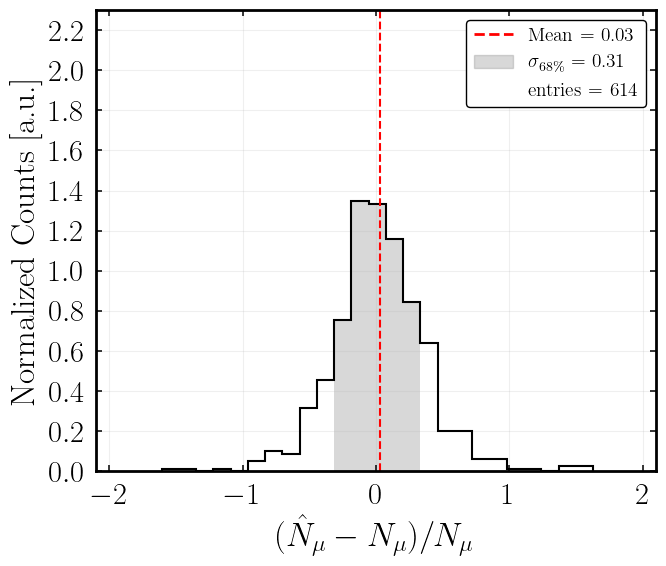

In [18]:
delta_n = []
m_ = m.values[0]
q_ = m.values[1]

for i in range(len(protons_info)):
    
    info_single_proton = protons_info[i]
    
    p_proton = np.asarray(info_single_proton[0])
    y_proton = np.asarray(info_single_proton[1])

    p_proton = p_proton[p_proton >= best_threshold]

    n_true = np.nansum(y_proton == 1)
    p_cum = np.nansum(p_proton)
    
    if n_true > 0:
        n_reco = n_estimated(m_, q_, p_cum)
        n_reco = float(np.asarray(n_reco).ravel()[0])
        
        delta_n.append((n_reco - n_true)/n_true)

delta_n = np.asarray(delta_n)
bias = np.mean(delta_n)

p16 = np.percentile(delta_n, 16)
p84 = np.percentile(delta_n, 84)

width_68 = (p84 - p16)/2   

print("Delta N statistics:")
print(f"Bias (mean) = {bias:.1f}")
print(f"68% half width = {width_68:.1f}")

fig, ax = plt.subplots(figsize=(7, 6))

counts, bins, _ = ax.hist(delta_n, bins=25, histtype="step", color="black", linewidth=1.5, density = True)

centers = 0.5 * (bins[:-1] + bins[1:])
mask = (centers >= p16) & (centers <= p84)

ax.bar(centers[mask], counts[mask], width=np.diff(bins)[mask], align="center", color="gray", alpha=0.3, edgecolor="none")
ax.axvline(bias, linestyle="--", linewidth = 1.5, color="red")

for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.tick_params(axis="both", which="major", labelsize=22, length=4)
ax.minorticks_off()

ax.set_xlabel(r"$(\hat{N}_{\mu} - N_{\mu})/N_{\mu}$", fontsize=24)
ax.set_ylabel("Normalized Counts [a.u.]", fontsize=24)

ax.set_xticks([-2, -1, 0, 1, 2])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2])


ax.set_xlim(-2.1, 2.1)
ax.set_ylim(0, 2.3)

ax.grid(True, alpha=0.2)

handles = [
    plt.Line2D([0], [0], color="red", linestyle="--", linewidth=2),
    plt.Rectangle((0, 0), 1, 1, color="gray", alpha=0.3),
    plt.Line2D([], [], linestyle="none")
]

labels = [
    f"Mean = {bias:.2f}",
    r"$\sigma_{68\%}$ = " f"{width_68:.2f}",
    f"entries = {len(delta_n)}"
]

ax.legend(handles, labels, fontsize=14, edgecolor="black", facecolor="white", framealpha=1.0)
plt.tight_layout()
plt.savefig("../pictures/100160TeV_025deg_4FF_180R175h_Black/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/nmureco_nmutrue_pmuOT_nmuNOT_bin5lenbin20_100160TeV_25z_13pe_500ns_0600d.pdf", dpi=300, bbox_inches="tight")


plt.show()

Delta N statistics:
Bias (mean) = 0.0
68% half width = 0.4


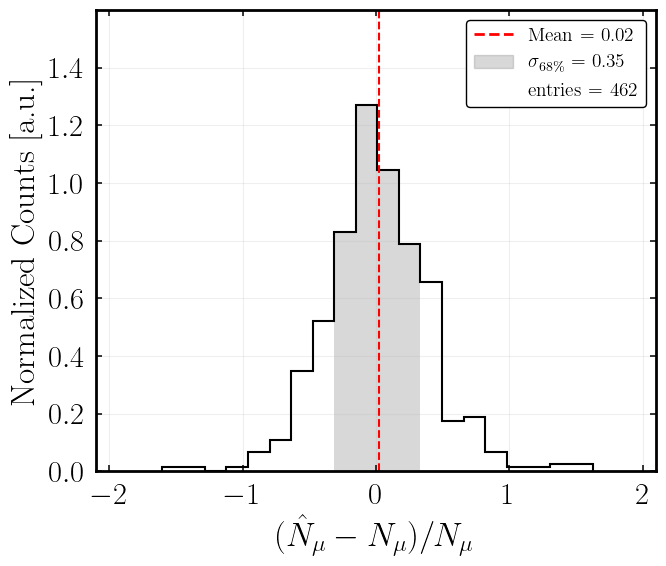

In [19]:
delta_n = []
m_ = m.values[0]
q_ = m.values[1]

for i in range(len(protons_info)):
    
    info_single_proton = protons_info[i]
    
    p_proton = np.asarray(info_single_proton[0])
    y_proton = np.asarray(info_single_proton[1])

    p_proton = p_proton[p_proton >= best_threshold]

    n_true = np.nansum(y_proton == 1)
    p_cum = np.nansum(p_proton)
    
    if n_true > 0 and n_true < 20:
        n_reco = n_estimated(m_, q_, p_cum)
        n_reco = float(np.asarray(n_reco).ravel()[0])
        
        delta_n.append((n_reco - n_true)/n_true)

delta_n = np.asarray(delta_n)
bias = np.mean(delta_n)

p16 = np.percentile(delta_n, 16)
p84 = np.percentile(delta_n, 84)

width_68 = (p84 - p16)/2   

print("Delta N statistics:")
print(f"Bias (mean) = {bias:.1f}")
print(f"68% half width = {width_68:.1f}")

fig, ax = plt.subplots(figsize=(7, 6))

counts, bins, _ = ax.hist(delta_n, bins=20, histtype="step", color="black", linewidth=1.5, density = True)

centers = 0.5 * (bins[:-1] + bins[1:])
mask = (centers >= p16) & (centers <= p84)

ax.bar(centers[mask], counts[mask], width=np.diff(bins)[mask], align="center", color="gray", alpha=0.3, edgecolor="none")
ax.axvline(bias, linestyle="--", linewidth = 1.5, color="red")

for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.tick_params(axis="both", which="major", labelsize=22, length=4)
ax.minorticks_off()

ax.set_xlabel(r"$(\hat{N}_{\mu} - N_{\mu})/N_{\mu}$", fontsize=24)
ax.set_ylabel("Normalized Counts [a.u.]", fontsize=24)

ax.set_xticks([-2, -1, 0, 1, 2])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4])


ax.set_xlim(-2.1, 2.1)
ax.set_ylim(0, 1.6)

ax.grid(True, alpha=0.2)

handles = [
    plt.Line2D([0], [0], color="red", linestyle="--", linewidth=2),
    plt.Rectangle((0, 0), 1, 1, color="gray", alpha=0.3),
    plt.Line2D([], [], linestyle="none")
]

labels = [
    f"Mean = {bias:.2f}",
    r"$\sigma_{68\%}$ = " f"{width_68:.2f}",
    f"entries = {len(delta_n)}"
]

ax.legend(handles, labels, fontsize=14, edgecolor="black", facecolor="white", framealpha=1.0)
plt.tight_layout()
plt.savefig("../pictures/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/Nmutrue_nmureco_nmutrue_pmuOT_nmuNOT_bin5lenbin20_100160TeV_25z_13pe_300ns_0600d.pdf", dpi=300, bbox_inches="tight")


plt.show()

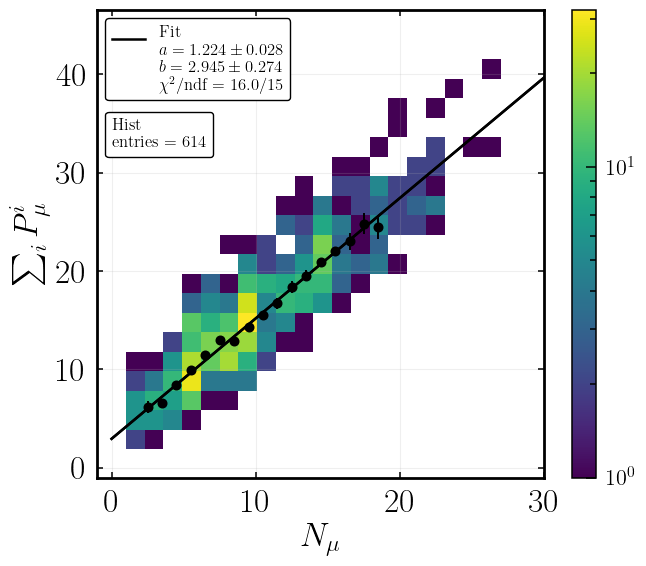

In [20]:


#################### ONLY PROBABILITIES ABOVE THRESHOLD, ONLY MUONS CORRESPONDING TO STATIONS ABOVE THRESHOLD #######################



import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from iminuit import Minuit

n_muons = []
p_cum = []

for i in range(len(protons_info)):
    info_single_proton = protons_info[i]

    p_proton = np.asarray(info_single_proton[0])
    y_proton = np.asarray(info_single_proton[1])

    mask_thr = p_proton >= best_threshold
    p_proton = p_proton[mask_thr]
    y_proton = y_proton[mask_thr]

    n_muons_proton = np.nansum(y_proton == 1)
    p_cum_proton = np.nansum(p_proton)

    n_muons.append(n_muons_proton)
    p_cum.append(p_cum_proton)

n_muons = np.asarray(n_muons)
p_cum = np.asarray(p_cum)

bin_width = 1
n_min = np.min(n_muons)
n_max = np.max(n_muons)

bins = np.arange(n_min, n_max + bin_width, bin_width)

bin_centers = []
mean_pr = []
err_pr = []
p_bin_centers = []

for i in range(len(bins) - 1):
    mask_bin = (n_muons >= bins[i]) & (n_muons < bins[i + 1])
    p_cum_bin = p_cum[mask_bin]
    

    if len(p_cum_bin) > 10:
        bin_centers.append(0.5 * (bins[i] + bins[i + 1]))
        mean_pr.append(np.mean(p_cum_bin))
        err_pr.append(np.std(p_cum_bin) / np.sqrt(len(p_cum_bin)))
        p_bin_centers.append(p_cum_bin)

bin_centers = np.asarray(bin_centers)
mean_pr = np.asarray(mean_pr)
err_pr = np.asarray(err_pr)

def linear_regr(x, a, b):
    return a * x + b

def chi2(a, b):
    return np.sum(((mean_pr - linear_regr(bin_centers, a, b)) / err_pr) ** 2)

m = Minuit(chi2, a = 1.0, b = 0.0)
m.errordef = Minuit.LEAST_SQUARES
m.migrad()
m.hesse()

chi2_val = m.fval
ndf = len(mean_pr) - len(m.parameters)

#n_fit = np.linspace(np.min(bin_centers), np.max(bin_centers), 300)
n_fit = np.linspace(0, 100, 300)
p_fit = linear_regr(n_fit, *m.values)

fig, ax = plt.subplots(figsize=(7, 6))

h = ax.hist2d(n_muons, p_cum, bins = 20, cmap="viridis", norm=colors.LogNorm(vmin=1))

ax.errorbar(bin_centers, mean_pr, yerr=err_pr, fmt="o", color="black", markersize=6, elinewidth=1.4, ecolor="black", markeredgecolor="black", markeredgewidth=1.2)
ax.plot(n_fit, p_fit, color="black", linewidth=1.8, label=(f"$a = {m.values['a']:.3f} \\pm {m.errors['a']:.3f}$\n" f"$b = {m.values['b']:.3f} \\pm {m.errors['b']:.3f}$\n" f"$\\chi^2$/ndf = {chi2_val:.1f}/{ndf}\nentries = {len(n_muons)}"))
for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.tick_params(axis="both", which="major", labelsize=24, length=4)
ax.minorticks_off()

ax.set_xlabel("$N_{\mu}$", fontsize=24)
ax.set_ylabel(r"$\sum_i P_{\mu}^{i}$", fontsize=24)

ax.set_xlim(-1, n_max + 3)
ax.set_ylim(-1, np.max(p_cum) + 5)

ax.grid(True, alpha=0.2)

cbar = plt.colorbar(h[3], ax=ax)
cbar.ax.tick_params(labelsize=16)

fit_line, = ax.plot(n_fit, p_fit, color="black", linewidth=1.8)

legend_fit = ax.legend([fit_line], [f"Fit\n$a = {m.values['a']:.3f} \\pm {m.errors['a']:.3f}$\n$b = {m.values['b']:.3f} \\pm {m.errors['b']:.3f}$\n$\\chi^2$/ndf = {chi2_val:.1f}/{ndf}"], fontsize=12, edgecolor="black", facecolor="white", framealpha=1.0, loc="upper left",handler_map={Line2D: OffsetLineHandler(y_offset=20)})
legend_data = ax.legend([plt.Line2D([], [], linestyle="none")], [f"Hist\nentries = {len(n_muons)}"], fontsize=12, edgecolor="black", facecolor="white", framealpha=1.0, loc="upper left", bbox_to_anchor=(0.0, 0.80), handlelength=0, handletextpad=0)
ax.add_artist(legend_fit)

plt.tight_layout()
plt.savefig("../pictures/100160TeV_025deg_4FF_180R175h_Black/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/pmuOTvsnmuOT_bin1lenbin10_100160TeV_25z_13pe_500ns_0600d.pdf", dpi=300, bbox_inches="tight")

plt.show()

Mean number of muons =  9.996742671009772


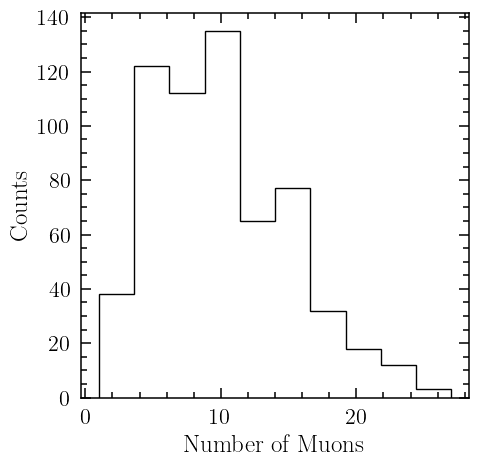

In [21]:
plt.hist(n_muons, color = "black", histtype = "step", bins = 10)
print("Mean number of muons = ", np.mean(n_muons))
plt.xlabel("Number of Muons")
plt.ylabel("Counts")
plt.show()

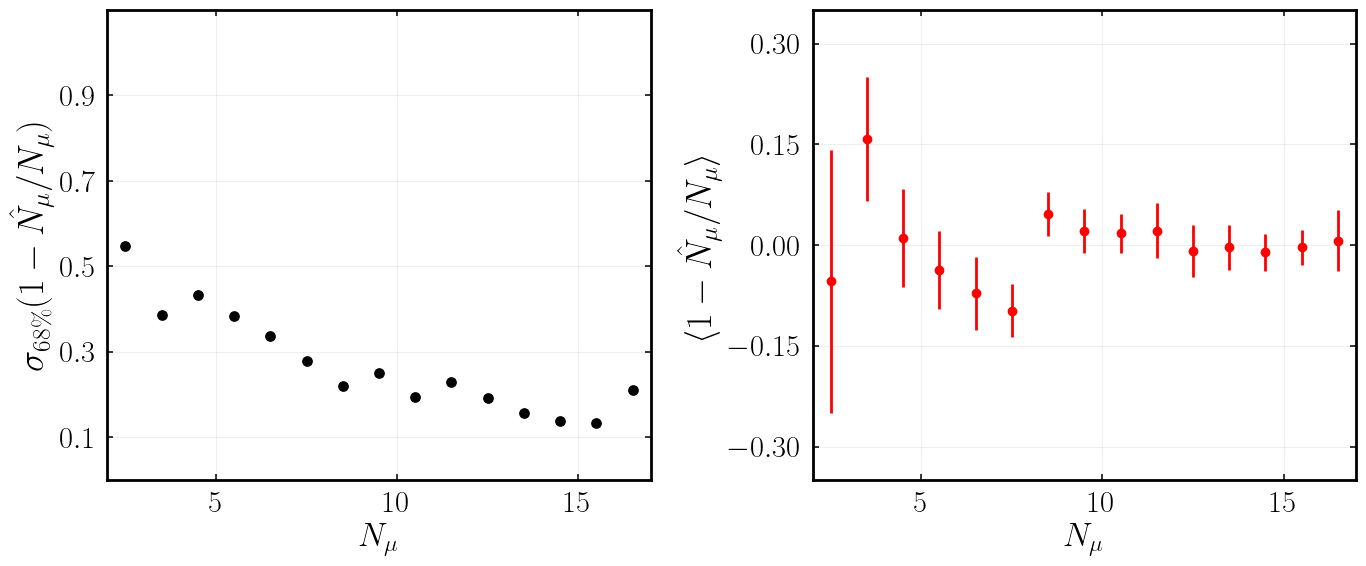

In [22]:
def n_estimated(m, q, p):
    a = 1 / m
    b = -q / m
    return a * p + b

m_ = m.values[0]
q_ = m.values[1]

def estimator(n_reco_, n_muons_):
    return 1 - n_reco_ / n_muons_

est_list = []
for i in range(len(bin_centers)):
    est = [1 - (n_estimated(m_, q_, p_bin_centers[i][j]) / bin_centers[i]) for j in range(len(p_bin_centers[i]))]
    est_list.append(est)

resolution = np.asarray([(np.percentile(k, 84) - np.percentile(k, 16)) / 2 for k in est_list])
bias = np.asarray([np.mean(k) for k in est_list])

bias_err = np.asarray([np.std(k, ddof=1) / np.sqrt(len(k)) if len(k) > 1 else np.nan for k in est_list])
#print(bias_err)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].scatter(bin_centers, resolution, color="black", s=45, edgecolors="black", linewidths=1.0)
#ax[1].scatter(bin_centers, bias, color="red", s=45, edgecolors="red", linewidths=1.0)
ax[1].errorbar(bin_centers, bias, yerr = bias_err, fmt="o", color="red", markersize=6, ecolor="red", markeredgecolor="red", markeredgewidth=1.0)

for i in range(2):
    for spine in ax[i].spines.values():
        spine.set_linewidth(2)
    ax[i].tick_params(axis="both", which="major", labelsize=22, length=4)
    ax[i].minorticks_off()
    ax[i].grid(True, alpha=0.2)
    ax[i].set_xlim(np.min(bin_centers) - 5, np.max(bin_centers) + 5)
    ax[i].set_xlabel(r"$N_{\mu}$", fontsize=24)

ax[0].set_ylabel(r" $\sigma_{68 \%} (1 - \hat{N_{\mu}}/N_{\mu})$", fontsize=26)
ax[1].set_ylabel(r"$\langle 1 - \hat{N}_{\mu}/N_{\mu} \rangle$", fontsize=26)

ax[0].set_xticks([0, 5, 10, 15, 20])
ax[1].set_xticks([0,5, 10,15, 20])

ax[0].set_yticks([0.1,  0.3,  0.5, 0.7,  0.9, ])
ax[1].set_yticks([-0.3, -0.15, 0, 0.15, 0.3])

ax[0].set_ylim(0, 1.1)
ax[1].set_ylim(-0.35, 0.35)
ax[0].set_xlim(2, 17)
ax[1].set_xlim(2, 17)

plt.tight_layout()
plt.savefig("../pictures/100160TeV_025deg_4FF_180R175h_Black/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/bias_variance_pmuOT_nmuOT_bin1lenbin10_100160TeV_25z_13pe_500ns_0600d.pdf", dpi=300, bbox_inches="tight")

plt.show()

Delta N statistics:
Bias (mean) = 0.07
68% half width = 0.25


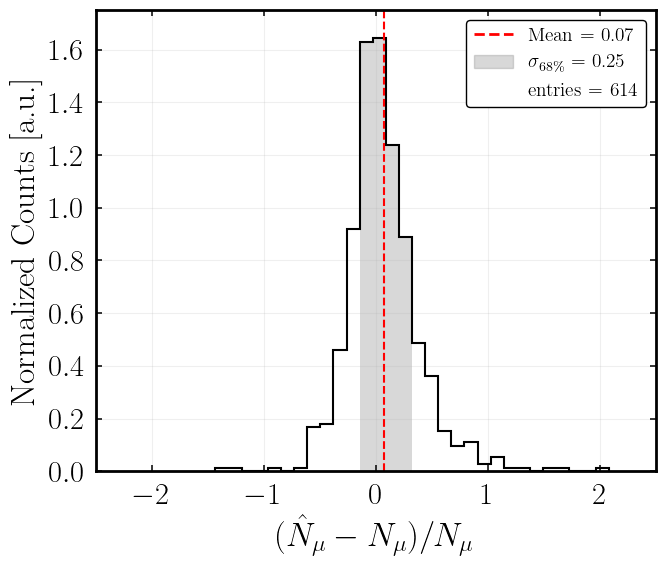

In [23]:
delta_n = []
m_ = m.values[0]
q_ = m.values[1]

for i in range(len(protons_info)):
    
    info_single_proton = protons_info[i]
    
    p_proton = np.asarray(info_single_proton[0])
    y_proton = np.asarray(info_single_proton[1])

    y_proton = y_proton[p_proton >= best_threshold]
    p_proton = p_proton[p_proton >= best_threshold]

    n_true = np.nansum(y_proton == 1)
    p_cum = np.nansum(p_proton)
    if n_true > 0:
        n_reco = n_estimated(m_, q_, p_cum)
        n_reco = float(np.asarray(n_reco).ravel()[0])
        
        delta_n.append((n_reco - n_true)/n_true)

delta_n = np.asarray(delta_n)
bias = np.mean(delta_n)

p16 = np.percentile(delta_n, 16)
p84 = np.percentile(delta_n, 84)

width_68 = (p84 - p16)/2   

print("Delta N statistics:")
print(f"Bias (mean) = {bias:.2f}")
print(f"68% half width = {width_68:.2f}")

fig, ax = plt.subplots(figsize=(7, 6))

counts, bins, _ = ax.hist(delta_n, bins = 30, histtype="step", color="black", linewidth=1.5, density = True)

centers = 0.5 * (bins[:-1] + bins[1:])
mask = (centers >= p16) & (centers <= p84)

ax.bar(centers[mask], counts[mask], width=np.diff(bins)[mask], align="center", color="gray", alpha=0.3, edgecolor="none")
ax.axvline(bias, linestyle="--", linewidth = 1.5, color="red")

for spine in ax.spines.values():
    spine.set_linewidth(2)

ax.tick_params(axis="both", which="major", labelsize=22, length=4)
ax.minorticks_off()

ax.set_xlabel(r"$(\hat{N}_{\mu} - N_{\mu})/N_{\mu}$", fontsize=24)
ax.set_ylabel("Normalized Counts [a.u.]", fontsize=24)

ax.set_xticks([-2, -1, 0, 1, 2])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6])


ax.set_xlim(-2.5, 2.5)
ax.set_ylim(0, 1.75)

ax.grid(True, alpha=0.2)

handles = [
    plt.Line2D([0], [0], color="red", linestyle="--", linewidth=2),
    plt.Rectangle((0, 0), 1, 1, color="gray", alpha=0.3),
    plt.Line2D([], [], linestyle="none")
]

labels = [
    f"Mean = {bias:.2f}",
    r"$\sigma_{68\%}$ = " f"{width_68:.2f}",
    f"entries = {len(delta_n)}"
]

ax.legend(handles, labels, fontsize=14, edgecolor="black", facecolor="white", framealpha=1.0)
plt.savefig("../pictures/100160TeV_025deg_4FF_180R175h_Black/XGB_IC_13peSM_13peBKG_13peTEST_d0600_500ns/nmureco_nmutrue_pmuOT_nmuOT_bin5lenbin20_100160TeV_25z_13pe_500ns_0600d.pdf", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()